# <center> L'algorithme de Dijkstra </center>

Considérons, dans un premier temps, le graphe de l'exemple du cours (bas de la page 1). 

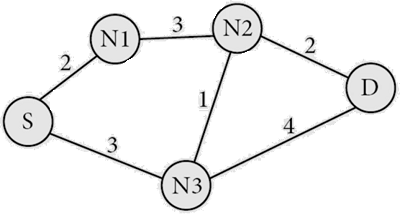

La structure de données du graphe est donnée sous la forme d’un dictionnaire décrite ci-dessous :

In [23]:
GraphType = dict[str, dict[str, int]]

G: dict[str, dict[str, int]] = {
    'S' : {'N1' : 2, 'N3' :3},
    'N1': {'S' : 2, 'N2' : 3},
    'N2': {'N1' : 3, 'N3' : 1, 'D' : 2},
    'N3': {'S' : 3, 'N2' : 1, 'D' : 4},
    'D' : {'N2' : 2, 'N3' : 4}
}


**Exercice :**

Implémenter, de la même façon, le graphe de l'exercice 1. 

On donnera comme étiquettes : R1 pour le sommet Routeur1, R2 pour le sommet Routeur2, etc...

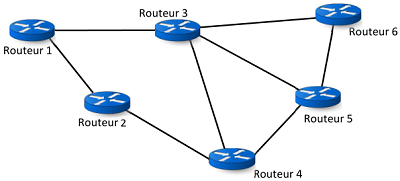

In [24]:
Graphe_routeurs: dict[str, dict[str, int]] = {
	'R1' : {'R2' : 1, 'R3' : 10},
    'R2' : {'R1' : 1, 'R4' : 22},
    'R3' : {'R1' : 10, 'R4' : 3, 'R5' : 4, 'R6' : 1},
    'R4' : {'R2' : 22, 'R3' : 3, 'R5' : 4},
    'R5' : {'R3' : 4, 'R4' : 4, 'R6' : 1},
    'R6' : {'R3' : 1, 'R5' :1}
}

On donne ci-dessous le script d'une fonction `voisins` prenant pour paramètre un graphe `g`, représenté sous la forme d'un dictionnaire, et une chaîne de caractères `s` correspondant au nom d'un sommet du graphe `g`. Cette fonction renvoie un dictionnaire où chaque clé est un voisin de `s` et où la valeur associée à la clé correspond au poids de l'arête entre le sommet `s` et cette clé.

In [25]:
def voisins(g: GraphType, s: str) -> dict[str, int]:
    """
    Renvoie un dictionnaire où chaque clé est un voisin de s et où la valeur associée à la 
    clé correspond au poids de l'arête entre le sommet s et la clé.
    """
    return g[s]

print(voisins(G,'S'))

print(voisins(Graphe_routeurs,'R1'))

{'N1': 2, 'N3': 3}
{'R2': 1, 'R3': 10}


## Algorithme de Dijkstra : pseudo-code 

Comme nous l'avons vu, l’algorithme de Dijkstra permet de déterminer, dans un graphe, le plus court chemin allant d’un sommet `depart` à un sommet `arrivee`, sans repasser deux fois par le même sommet. 

Pour cela, on commence par définir trois dictionnaires : `couleurs`, `poids_sommets` et `precedents`. 
Les clés de ces dictionnaires sont les sommets du graphe. Ainsi, pour un graphe ayant 8 sommets nommés A, B, C, D, E, F, G et H, on a :

`couleurs = {'A' : 'blanc', 'B' : 'blanc', 'C' : 'blanc', 'D' : 'blanc', 'E' : 'blanc', 'F' : 'blanc', 'G' : 'blanc', 'H' : 'blanc'}`  

Un sommet sera :  
•	 soit colorié en `blanc` et, dans ce cas, on dira que le sommet est *non traité* ;  
•	 soit colorié en `noir` et, dans ce cas, on dira que le sommet est *traité*.  

Le dictionnaire `poids_sommets` ci-dessous permet d’attribuer un poids à chaque sommet du graphe. 

`poids_sommets = {'A' : inf, 'B' : inf,  'C' : inf, 'D' : inf, 'E' : inf, 'F' : inf, 'G' : inf, 'H' : inf}`

**Remarque :**  
Le module `math` de Python dispose d’une constante `inf` permettant de représenter l’infini.


In [26]:
from math import inf

print(3.4 < inf)

True


De manière générale, l’instruction `a < inf` renvoie `True`, quelque soit le contenu de la variable `a` de type `float` ou `int`. Ainsi, le dictionnaire `poids_sommets` permet d’attribuer initialement un poids infini à chaque sommet du graphe. 

Enfin, le dictionnaire `precedents` ci-dessous sera utile pour la lecture du chemin final : il permet, pour chaque sommet, de mémoriser le sommet qui le précède.  

Par exemple, si la clé `'F'` contient la valeur `'H'`, alors on sait que juste avant d’arriver sur le sommet `'F'`, on se trouvait sur le sommet `'H'`.  

Initialement, toutes les clés prennent la valeur `None`. 

`precedents = {'A' : None, 'B' : None, 'C' : None, 'D' : None, 'E' : None, 'F' : None, 'G' : None, 'H' : None}`


Voici enfin l'algorithme de Dijstra écrit en langage usuel dans lequel `depart` est une variable contenant le nom du sommet d'où part le chemin le plus court : 

```
    Affecter la valeur de depart à une variable s
    Affecter la valeur 0 à la clé s dans le dictionnaire poids_sommets 
    
    Tant que 'blanc' est une valeur du dictionnaire couleurs: 

        Affecter la valeur 'noire' à la clé s dans le dictionnaire couleurs
        Rechercher les voisins du sommet s
        
        Pour chaque voisin v du sommet s :
            Si la valeur de v dans le dictionnaire couleurs n'est pas 'noire':
                Stocker, dans une variable d, la somme du poids du sommet s et du poids de l'arête entre v et s.

                Si le poids du sommet v est soit égal à inf, soit strictement supérieur à d :
                    Affecter la valeur de d à la clé v dans le dictionnaire poids_sommets
                    Créer la clé v dans le dictionnaire precedents et lui associer la valeur de s. 
        
        Affecter à s le sommet de poids minimum parmi les sommets 'blancs'

```

**Question :**  
Tester cet algorithme à la main sur le graphe ci-dessous, en prenant comme sommet de départ le sommet A.   

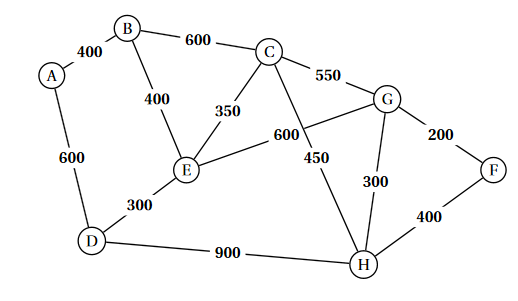


## Algorithme de Dijkstra : implémentation en Python

**Question 1 :**  
Ecrire une fonction `sommet_de_poids_minimum` qui prend en paramètres deux dictionnaires : `dico_couleurs` et `dico_poids`. 

Cette fonction renvoie, parmi les sommets non encore traités (donc `blancs`), le sommet dont le poids est le plus petit.

Préconditions : 

* `dico_couleurs` et `dico_poids` sont deux dictionnaires ayant les mêmes clés : les sommets du graphe. 
* `dico_couleurs` : à chaque sommet est associée sa couleur (`"blanc"` : le sommet n'a pas encore été traité ;  `"noir"` : le sommet a déjà été traité).
* `dico_poids` : à chaque sommet est accocié son poids, avec la valeur `None` pour indiquer un poids infini. 



Exemple d'exécution (prenez le temps de bien le comprendre avant de poursuivre) : 
* `couleurs = {"A" : "blanc", "B" : "noir"  , "C" : "noir", "D" : "noir", "E" : "blanc","T" : "blanc", "V" : "blanc", "R" : "blanc", "N" : "blanc"}` ;


* `poids = {"A" : 54, "B" : 19  , "C" : 18, "D" : 0, "E" : 36,"T" : 82, "V" : None, "R" : None, "N" : None}`

L'appel `sommet_de_poids_minimum(couleurs, poids)` renvoie `"E"`.


In [27]:
from math import inf

def sommet_de_poids_minimum(dico_couleur: dict[str, str], dico_poids: dict[str, float]) -> str:
    """dico_couleur et dico_poids doivent avoir les mêmes clés : les sommets du graphe. 
    dico_couleur : à chaque sommet, on associe sa couleur ("blanc" : non traité ; "noir" : traité)
    dico_poids : à chaque sommet, on associe son poids.
    
    La fonction sommet_de_poids_minimum retourne, parmi les sommets non encore traités, 
    le sommet dont le poids est le plus petit"""
    
    minimum: float = inf
    sommet_poids_min: str = ""
    
    for key in dico_couleur.keys():
        if (dico_couleur[key] == "blanc") and (dico_poids[key] < minimum):
            sommet_poids_min = key
            minimum = dico_poids[key]
   
    return sommet_poids_min


Votre code devra passer le test suivant : 

In [28]:
couleurs: dict[str, str] = {
    "A": "blanc", 
    "B": "noir"  ,
    "C": "noir", 
    "D": "noir", 
    "E": "blanc",
    "T": "blanc",
    "V": "blanc", 
    "R": "blanc", 
    "N": "blanc",
}

poids: dict[str, float] = {
    "A": 54, 
    "B": 19  , 
    "C": 18, 
    "D": 0, 
    "E": 36,
    "T": 82, 
    "V": inf, 
    "R": inf, 
    "N": inf,
}

assert sommet_de_poids_minimum(couleurs, poids) == "E"

**Question 2**

En s'appuyant sur l'algorithme donné ci-dessus en langage usuel, compléter le script de la fonction `dijkstra` qui prend en paramètres `graphe`, un dictionnaire représentant un graphe, et `depart`, une chaîne de caractères représentant le nom du sommet de départ. Cette fonction doit renvoyer le dictionnaire `precedents`  : chaque clé de ce dictionnaire est un sommet du graphe et la valeur associée est le nom du dernier sommet ayant conduit à ce sommet clé. 
    

In [29]:
from math import inf

def dijkstra(graphe: GraphType, depart: str) -> dict[str, str | None]:
    # Initialisation des 3 dictionnaires
    couleurs: dict[str, str] = {}                    
    poids_sommets: dict[str, float] = {}
    precedents: dict[str, str | None] = {depart: None}
    
    for key in graphe:
        # Au départ, tous les sommets sont non traités, donc blancs
        couleurs[key] = "blanc"
        # Au départ, tous les sommets sont affectés d'un poids infini     
        poids_sommets[key] = inf     
        
    # s est le sommet en cours de traitement, donc le sommet de départ ici
    s: str = depart      
    # s est le sommet de départ, la distance de s à lui-même est 0.      
    poids_sommets[s] = 0 
    
    # Tant qu'il reste des sommets à traiter. 
    while "blanc" in couleurs.values(): 
        # Le sommet est traité : on le colorie en noir.
        couleurs[s] = "noir"             
        dico_voisins: dict[str, int] = voisins(graphe, s)
        
        for v in dico_voisins:               
            if couleurs[v] != "noire": 
                # poids du sommet en cours de traitement + poids de l'arête entre s et v
                d = poids_sommets[s] + dico_voisins[v]
            
                if (poids_sommets[v] == inf) or (poids_sommets[v] > d):
                    # distance est plus petite que l'ancien poids: distance devient le nouveau
                    # poids de v et on retient que le prédécesseur de v est s: 
                    # création de la clé v dans precedents, associée à la valeur s. 
                    poids_sommets[v] = d
                    precedents[v] = s
        
        # Mise à jour du prochain sommet à traiter: parmi les sommets non traités,
        # il s'agit du sommet dont le poids est le plus faible. 
        s = sommet_de_poids_minimum(couleurs, poids_sommets)  
        
    
    print("Dictionnaire des prédécesseurs :")
    print(precedents)
    print("Dictionnaire des poids des sommets : ")
    print(poids_sommets)
        
    return precedents
    

In [30]:
assert dijkstra(Graphe_routeurs, "R2") == {'R2': None, 'R1': 'R2', 'R4': 'R3', 'R3': 'R1', 'R5': 'R6', 'R6': 'R3'}

Dictionnaire des prédécesseurs :
{'R2': None, 'R1': 'R2', 'R4': 'R3', 'R3': 'R1', 'R5': 'R6', 'R6': 'R3'}
Dictionnaire des poids des sommets : 
{'R1': 1, 'R2': 0, 'R3': 11, 'R4': 14, 'R5': 13, 'R6': 12}


**Question 3**  
Ecrire une fonction `plus_court_chemin` qui prend en paramètres `graphe`, un dictionnaire représentant un graphe, le sommet de depart `depart` et le sommet d'arrivée `arrivee`. Cette donction doit renvoyer une chaîne de caractères correspondant au chemin le plus court allant du sommet `depart` au sommet `arrivee`. 

Indication : la lecture du plus court chemin se fait à partir du dictionnaire des précédents `precedents` renvoyé par la fonction `dijkstra`, en remontant le chemin depuis le sommet d'arrivée.

Par exemple, avec 

`precedents = {'R2': None, 'R1': 'R2', 'R4': 'R3', 'R3': 'R1', 'R5': 'R3', 'R6': 'R3'}`
    
le chemin le plus court entre les sommets `R2` et `R6` est `R2 R1 R3 R6`.

In [ ]:
def plus_court_chemin(graphe: GraphType, depart: str, arrivee: str) -> str:
    dico_precedents = dijkstra(graphe, depart)
    
    # Lecture du chemin le plus court à partir du dictionnaire des précédents. 
    # On remonte le chemin depuis le sommet d'arrivée
    
    sommet: str = arrivee
    chemin: str = arrivee   # On initialise le chemin avec uniquement le sommet d'arrivée. 
        
    while (dico_precedents[sommet] != None):
        chemin = dico_precedents[sommet] + " " + chemin
        sommet = dico_precedents[sommet]
        
    return chemin    

In [32]:
assert plus_court_chemin(Graphe_routeurs, "R2", "R6") == "R2 R1 R3 R6" 

Dictionnaire des prédécesseurs :
{'R2': None, 'R1': 'R2', 'R4': 'R3', 'R3': 'R1', 'R5': 'R6', 'R6': 'R3'}
Dictionnaire des poids des sommets : 
{'R1': 1, 'R2': 0, 'R3': 11, 'R4': 14, 'R5': 13, 'R6': 12}


**Question 4**

Implémenter les graphes des exercices 2, 3 et 4 du document de cours. 

Appeler la fonction `plus_court_chemin` sur chacun de ces trois graphes et vérifier que les résultats obtenus sont cohérents avec ceux que vous aviez obtenus en faisant fonctionner l'algorithme de Dijkstra à la main. 


In [ ]:
# Exercice 4 
campagne: dict[str, dict[str, int]] = {
    'A' : {'B' : 400, 'D' : 600},
    'B' : {'A' : 400, 'C' : 600, 'E' : 400},
    'C' : {'B' : 600, 'E' : 350, 'G' : 550, 'H' : 300},
    'D' : {'A' : 600, 'E' : 300, 'H' : 900},
    'E' : {'B' : 400, 'C' : 350, 'D' : 300, 'G' : 600},
    'F' : {'G' : 200, 'H' : 400},
    'G' : {'C' : 550, 'E' : 600, 'H' : 300, 'F' : 200},
    'H' : {'D' : 900, 'C' : 450, 'G' : 300, 'F' : 400}
}

plus_court_chemin(campagne, "A", "F")

Dictionnaire des prédécesseurs :
{'A': None, 'B': 'A', 'D': 'A', 'C': 'B', 'E': 'B', 'H': 'C', 'G': 'E', 'F': 'G'}
Dictionnaire des poids des sommets : 
{'A': 0, 'B': 400, 'C': 1000, 'D': 600, 'E': 800, 'F': 1600, 'G': 1400, 'H': 1300}


'A B E G F'